In [33]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import torchvision.datasets
from torchvision import transforms

import os
from tqdm import tqdm

In [34]:
class_names = ['Cat', 'Dog']

In [35]:
def getdevice():
    if torch.cuda.is_available():
        return 'cuda'
    else:
        return 'cpu'

def savemodel(model, path):
    torch.save(model.state_dict(), path)

# def saveall(model, optimizer, loss, epoch, path):
def saveall(model, optimizer, epoch, path):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        # 'loss': loss,
        'epoch': epoch
    }, path)

def loadmodel(model, path):
    # return model.load_state_dict(torch.load(path, map_location=getdevice()))
    # return model.load_state_dict(torch.load(path, weights_only=True))
    model.load_state_dict(torch.load(path, weights_only=True))

def loadall(model, optimizer, path):
    cp = torch.load(path, weights_only=True)
    model.load_state_dict(cp['model_state_dict'])
    optimizer.load_state_dict(cp['optimizer_state_dict'])
    # return cp['loss'], cp['epoch']
    return cp['epoch']


In [36]:
class PetsNet(torch.nn.Module):
    def __init__(self):
        super(PetsNet, self).__init__()

        # pre-normalization
        self.bn0 = torch.nn.BatchNorm2d(num_features=3)

        # layer 1: 224x224x3
        self.conv1 = torch.nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3, padding=1)
        self.act1 = torch.nn.ReLU()
        self.bn1 = torch.nn.BatchNorm2d(num_features=4)
        self.mp1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 2: 112x112x4
        self.conv2 = torch.nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, padding=1)
        self.act2 = torch.nn.ReLU()
        self.bn2 = torch.nn.BatchNorm2d(num_features=8)
        self.mp2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 3: 56x56x8
        self.conv3 = torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.act3 = torch.nn.ReLU()
        self.bn3 = torch.nn.BatchNorm2d(num_features=16)
        self.mp3 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 4: 28x28x16
        self.conv4 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.act4 = torch.nn.ReLU()
        self.bn4 = torch.nn.BatchNorm2d(num_features=32)
        self.mp4 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 5: 14x14x32
        self.conv5 = torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.act5 = torch.nn.ReLU()
        self.bn5 = torch.nn.BatchNorm2d(num_features=64)
        self.mp5 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 6: 7x7x64
        self.fc1 = torch.nn.Linear(7*7*64, 512)
        self.act6 = torch.nn.Tanh()
        self.bn6 = torch.nn.BatchNorm1d(num_features=512)

        # layer 7: 1x512
        self.fc2 = torch.nn.Linear(512, 128)
        self.act7 = torch.nn.Tanh()
        self.bn7 = torch.nn.BatchNorm1d(num_features=128)

        # layer 8: 1x128
        self.fc3 = torch.nn.Linear(128, 2)

    def forward(self, x):
        x = self.bn0(x)

        x = self.conv1(x)
        x = self.act1(x)
        x = self.bn1(x)
        x = self.mp1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.bn2(x)
        x = self.mp2(x)

        x = self.conv3(x)
        x = self.act3(x)
        x = self.bn3(x)
        x = self.mp3(x)

        x = self.conv4(x)
        x = self.act4(x)
        x = self.bn4(x)
        x = self.mp4(x)

        x = self.conv5(x)
        x = self.act5(x)
        x = self.bn5(x)
        x = self.mp5(x)

        x = x.view(x.size(0), x.size(1)*x.size(2)*x.size(3))

        x = self.fc1(x)
        x = self.act6(x)
        x = self.bn6(x)

        x = self.fc2(x)
        x = self.act7(x)
        x = self.bn7(x)

        x = self.fc3(x)

        return x

In [37]:
# net = PetsNet()
# optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
# loss = torch.nn.CrossEntropyLoss()
# epoch = loadall(model=net, optimizer=optimizer, path='./model.v3.pt')
# net.eval()
# print(epoch)

In [38]:
net = PetsNet()
# loadmodel(model=net, path='./model.pt')
# net.eval()

In [39]:
net.load_state_dict(torch.load('./model.pt', weights_only=True))
net.eval();

In [40]:
image = plt.imread('./OxfordPets/test/oxford-iiit-pet/images/Abyssinian_1.jpg')

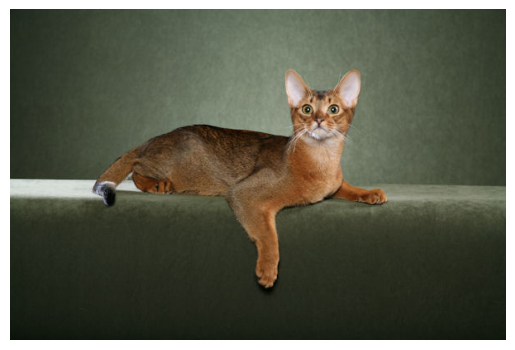

In [41]:
plt.imshow(image)
plt.axis('off')
plt.show()

In [42]:
# torch.clip(torch.tensor(image).permute(2,0,1).unsqueeze(0).float()/255., min=0., max=1.).max()
# img = (torch.tensor(image).permute(2,0,1).unsqueeze(0)/255.)

In [43]:
# img.shape

In [44]:
resize = transforms.Resize(224, interpolation=transforms.InterpolationMode.NEAREST)
crop = transforms.CenterCrop(size=224)

In [45]:
# im = crop(resize(img))

In [46]:
# im.shape

In [47]:
im = crop(resize(torch.tensor(image).permute(2,0,1).unsqueeze(0)/255.))

In [48]:
class_names[net.forward(im).argmax(dim=1)]

'Dog'